# Building an LSTM from Scratch

This notebook builds an LSTM (Long Short-Term Memory) unit from the ground up using PyTorch.

We will:
1. Understand **why** LSTMs exist (vanishing gradients in vanilla RNNs)
2. Define and wire the gates together into a complete `LSTMCell`
4. Train a **character-level language model** on the same names dataset as makemore
5. Validate our implementation against PyTorch's built-in `nn.LSTM`
6. Visualize what the gates are actually doing


## 1. Motivation: The Vanishing Gradient Problem

A vanilla RNN computes its hidden state as:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

During backpropagation through time (BPTT), the gradient flows through many matrix multiplications by $W_{hh}$. If the largest singular value of $W_{hh}$ is less than 1, gradients **shrink exponentially** with each time step — the vanishing gradient problem. This makes it nearly impossible for a vanilla RNN to learn long-range dependencies.

The LSTM (Hochreiter & Schmidhuber, 1997) solves this by introducing a **cell state** $C_t$ that acts as a "conveyor belt" — information can flow along it almost unchanged, bypassing the nonlinear transformations that squash gradients.

## 2. Data Preparation

We'll use the same **names dataset** as makemore — a list of ~32K human names. Each name is a sequence of characters. We'll train the LSTM to predict the next character given all previous characters in a name.

In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random
%matplotlib inline

In [64]:
# read it in to inspect it
with open('assets/names.txt', 'r', encoding='utf-8') as f:
    words = f.read().splitlines()
print(f'Number of names: {len(words)}')
print(f'First 8: {words[:8]}')

Number of names: 108
First 8: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [65]:
# Build character vocabulary — same as makemore
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}  # string to index
itos = {i+1: s for i, s in enumerate(chars)}   # index to string

itos[0] = '.'               # special end-of-sequence
vocab_size = len(stoi) + 1  # +1 for the '.' token

PAD_IDX = vocab_size        # reserve the next free id
itos[PAD_IDX] = '<pad>'     # padding token
vocab_size += 1             # vocab now includes the pad token

print(f'Vocabulary size: {vocab_size}')
print(f'Characters:') 
print([itos[i] for i in range(vocab_size)])

Vocabulary size: 28
Characters:
['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '<pad>']


In [66]:
# Encode a name: ".emma." → [0, 14, 22, 22, 0, 0]
def encode(name):
    """Encode a name string to a list of character indices.
    Prepends '.' as start token, appends '.' as end token.
    """
    return [0] + [stoi[c] for c in name] + [0]

# Decode: list of indices → string
def decode(indices):
    """Decode a list of character indices back to a string."""
    return ''.join(itos[i] for i in indices)

# Example
encoded = encode('emma')
print(f'"emma" → {encoded}')
print(f'Decoded: "{decode(encoded)}"')

# Show input/target pairs for training
print('\nTraining pairs (input → target):')
for i in range(len(encoded) - 1):
    print(f'  "{decode([encoded[i]])}" → "{decode([encoded[i+1]])}"')

"emma" → [0, 5, 13, 13, 1, 0]
Decoded: ".emma."

Training pairs (input → target):
  "." → "e"
  "e" → "m"
  "m" → "m"
  "m" → "a"
  "a" → "."


## 3. The LSTM Equations

An LSTM cell maintains two state vectors:
- **$h_t$** — hidden state (short-term memory, output)
- **$C_t$** — cell state (long-term memory, internal conveyor belt)

At each time step, three **gates** control information flow:

| Gate | Formula | Purpose |
|------|---------|----------|
| **Forget Gate** $f_t$ | $\sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ | What to **discard** from $C_{t-1}$ |
| **Input Gate** $i_t$ | $\sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ | What **new info** to store |
| **Candidate** $g_t$ | $\tanh(W_g \cdot [h_{t-1}, x_t] + b_g)$ | Candidate values to **add** to cell state |
| **Output Gate** $o_t$ | $\sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$ | What part of $C_t$ to **expose** as $h_t$ |

Cell state update (the core):
$$C_t = f_t \odot C_{t-1} + i_t \odot g_t$$

Hidden state update:
$$h_t = o_t \odot \tanh(C_t)$$

Key insight: the cell state $C_t$ has a **linear self-loop** ($f_t \odot C_{t-1}$). When $f_t \approx 1$, gradient flows through unchanged — no vanishing!

### 3.1 The Forget Gate

The forget gate decides **what information to throw away** from the cell state:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

It looks at the previous hidden state $h_{t-1}$ and the current input $x_t$, and outputs a number between 0 and 1 for each dimension of the cell state. A value of 1 means "completely keep this", 0 means "completely forget this".

**Intuition**: When processing a new name like "emmeline" after seeing "emma", the forget gate should keep the "e-m-m" pattern memory but might forget older context.

### 3.2 The Input Gate + Candidate Cell State

The input gate has **two parts** working together:

1. **$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$** — decides which values to update
2. **$g_t = \tanh(W_g \cdot [h_{t-1}, x_t] + b_g)$** — creates candidate values

These are multiplied together: $i_t \odot g_t$. Only the dimensions where $i_t$ is high will contribute new information to the cell state.

**Intuition**: When we see the letter 'm' in "emma", the input gate might activate for dimensions related to "double letter" patterns, while the candidate provides the actual values to store.

### 3.3 The Output Gate

The output gate decides **what part of the cell state to expose** as the hidden state:

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

The cell state $C_t$ goes through `tanh` (to squash to [-1, 1]), then is filtered by the output gate. This is the only part of the LSTM that's visible to the outside world.

**Intuition**: When predicting the next letter in "emma", the output gate might expose the "vowel after double-consonant" pattern from the cell state while suppressing irrelevant dimensions.

### 3.4 Gate Activations: Sigmoid and Tanh

LSTM gates use two activation functions:
- **$\sigma$ (sigmoid)**: squashes values to [0, 1]. Used by all three gates. Values near 0 = "block", near 1 = "pass through".
- **$\tanh$**: squashes values to [-1, 1]. Used for the candidate cell state. Provides a centered, normalized candidate value.

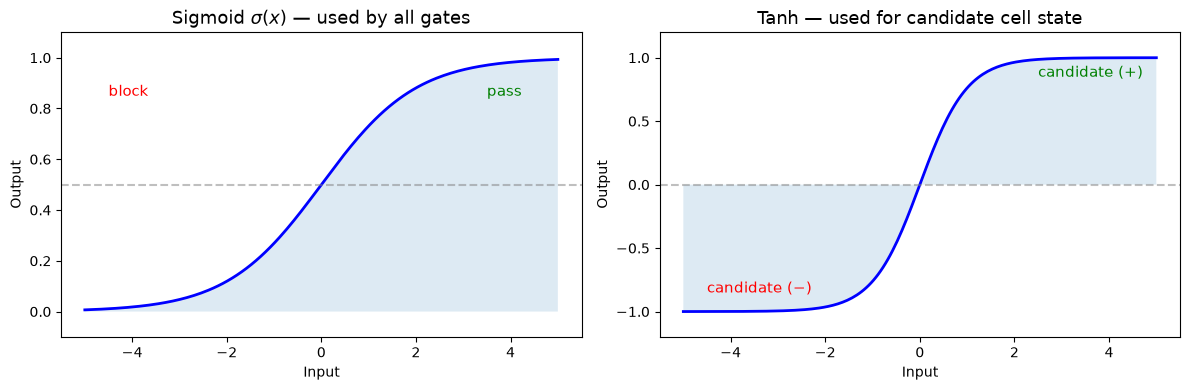

In [89]:
# Visualize the two activation functions
x = torch.linspace(-5, 5, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Sigmoid
y_sig = torch.sigmoid(x)
ax1.plot(x, y_sig, 'b-', linewidth=2)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Sigmoid $\sigma(x)$ — used by all gates', fontsize=13)
ax1.set_xlabel('Input'); ax1.set_ylabel('Output')
ax1.set_ylim(-0.1, 1.1)
ax1.fill_between(x, 0, y_sig, alpha=0.15)
ax1.text(-4.5, 0.85, 'block', color='red', fontsize=11)
ax1.text(3.5, 0.85, 'pass', color='green', fontsize=11)

# Tanh
y_tanh = torch.tanh(x)
ax2.plot(x, y_tanh, 'b-', linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Tanh — used for candidate cell state', fontsize=13)
ax2.set_xlabel('Input'); ax2.set_ylabel('Output')
ax2.set_ylim(-1.2, 1.2)
ax2.fill_between(x, 0, y_tanh, alpha=0.15)
ax2.text(-4.5, -0.85, 'candidate (−)', color='red', fontsize=11)
ax2.text(2.5, 0.85, 'candidate (+)', color='green', fontsize=11)

plt.tight_layout()
plt.show()

## 4. The Complete LSTMCell

Now we wire all four gates together into a single LSTM cell. This is the moment where the individual pieces become a coherent mechanism.

The cell state update is the heart of the LSTM:

$$C_t = f_t \odot C_{t-1} + i_t \odot g_t$$

Notice: this is just **addition and element-wise multiplication**. No matrix multiplication of $C_{t-1}$, no nonlinearity applied directly to $C$. This is why gradients flow so well through the cell state — it's essentially a linear path.

In [108]:
class LSTMCell(nn.Module):
    
    def __init__(self, input_size, hidden_size):
        super().__init__()
        combined_size = input_size + hidden_size
        self.W_f = nn.Linear(combined_size, hidden_size)
        self.W_i = nn.Linear(combined_size, hidden_size)
        self.W_g = nn.Linear(combined_size, hidden_size)
        self.W_o = nn.Linear(combined_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, state):
        
        # B, _ = x.shape
       
        h_prev, c_prev = state
        print(f'x.shape: {x}')
        print(f'h_prev: {h_prev}')
        # print(f'c_prev: {c_prev.shape}')
        combined = torch.cat([x, h_prev], dim=-1)
        print(f'combined shape: {combined}')
        
        f_t = torch.sigmoid(self.W_f(combined))
        i_t = torch.sigmoid(self.W_i(combined))
        g_t = torch.tanh(self.W_g(combined))
        o_t = torch.sigmoid(self.W_o(combined))

        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        print(f'h_t: {h_t}')
        
        return h_t, c_t

In [109]:
# Let's trace through a full name step by step
print('Processing "emma" character by character:')
print('=' * 60)

name = 'emma'
encoded_name = encode(name)  # [0, 14, 22, 22, 0, 0] (with start/end tokens)
print(f'Encoded: {encoded_name} = {"." + name + "."}')

hidden_size = 64

h = torch.zeros(1, hidden_size)
c = torch.zeros(1, hidden_size)

lstm_manual = LSTMCell(input_size=vocab_size, hidden_size=hidden_size)

for idx in encoded_name:
    x_t = F.one_hot(torch.tensor([idx]), vocab_size).float()
    h, c = lstm_manual(x_t, (h, c))
    # print(f'x_t.shape: {x_t.shape}')
    # print(f'h_t shape: {h.shape}')
    # print(f'c_t shape: {c.shape}')
    char = itos[idx]
    print(f'  char="{char}" → |h|={h.norm().item():.4f}, |C|={c.norm().item():.4f}')

print(f'\nFinal hidden state norm: {h.norm().item():.4f}')
print(f'Final cell state norm:   {c.norm().item():.4f}')
print(f'\nNotice: cell state norm > hidden state norm — c accumulates more information')

Processing "emma" character by character:
Encoded: [0, 5, 13, 13, 1, 0] = .emma.
x.shape: tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
h_prev: tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
combined shape: tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.]])
h_t: tensor([[ 0.0259, -0.0093, -0.0032,  0.0

## 5. The Full Language Model: CharLSTM

Now we wrap our LSTM cell into a complete character-level language model. The architecture mirrors the makemore approach:

```
Character (int) → Embedding → LSTM (unrolled over sequence) → Linear → logits → CrossEntropy
```

Key design choice: instead of using `nn.LSTM` (which handles the unrolling internally), we manually unroll our custom `LSTMCell` over each character in the name. This makes the data flow crystal clear and keeps us true to the "from scratch" philosophy.

In [70]:
class charLSTM(nn.Module):

    def __init__(self, input_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(input_size, emb_size, padding_idx=PAD_IDX)
        self.lstm_cell = LSTMCell(emb_size, hidden_size)
        self.fc = nn.Linear(hidden_size, input_size)
        self.hidden_size = hidden_size

    def forward(self, x):
        """
        Args:
            x: tensor of batch of character indices, shape (batch, seq_len,)
        Returns:
            logits: shape (batch, seq_len, vocab_size) — predictions for next char at each step
        """

        # Embed all characters at once
        embs = self.emb(x)  # (batch, seq_len, emb_size)
        # print(f'embs.shape: {embs.shape}')
        
        B, T, C = embs.shape

        h = torch.zeros(B, self.hidden_size, dtype=embs.dtype)
        c = torch.zeros(B, self.hidden_size, dtype=embs.dtype)
        
        logits_list = []
        
        for t in range(T):
            h, c = self.lstm_cell(embs[:, t, :], (h, c))
            logits_t = self.fc(h)  # (B, vocab_size)
            logits_list.append(logits_t)
        return torch.stack(logits_list, dim=1)  # (B, T, vocab_size)

### 5.1 Verify model input/outputs on sample data

In [71]:
from torch.nn.utils.rnn import pad_sequence

input_size, emb_size, hidden_size = vocab_size, 24, 128
model = charLSTM(input_size, emb_size, hidden_size)

names_list = ['emma', 'alice']
encoded_names = [torch.tensor(encode(name)) for name in names_list]

idx_batch_seq = pad_sequence(encoded_names, batch_first=True, padding_value=PAD_IDX)
print(f'idx_batch_seq.shape: {idx_batch_seq.shape}')

logits = model(idx_batch_seq)
print(f'Output logits shape: {logits.shape} → (batch, seq_len, vocab_size)')

print(f'\nAt each position, logits predict the next character:')
for b, name in enumerate(names_list):
    print(f'Sequence {b}: "{name}"')
    seq_len = len(encoded_names[b])  # actual (unpadded) length of this name
    for t in range(seq_len - 1):
        idx = idx_batch_seq[b, t]
        target_idx = idx_batch_seq[b, t + 1]
        pred_idx = logits[b, t].argmax().item()
        # correct = "✓" if pred_idx == target_idx.item() else "✗"
        print(f'  "{itos[idx.item()]}" → predicted: "{itos[pred_idx]}" (actual: "{itos[target_idx.item()]}")')

idx_batch_seq.shape: torch.Size([2, 7])
Output logits shape: torch.Size([2, 7, 28]) → (batch, seq_len, vocab_size)

At each position, logits predict the next character:
Sequence 0: "emma"
  "." → predicted: "u" (actual: "e")
  "e" → predicted: "t" (actual: "m")
  "m" → predicted: "t" (actual: "m")
  "m" → predicted: "z" (actual: "a")
  "a" → predicted: "z" (actual: ".")
Sequence 1: "alice"
  "." → predicted: "u" (actual: "a")
  "a" → predicted: "t" (actual: "l")
  "l" → predicted: "b" (actual: "i")
  "i" → predicted: "o" (actual: "c")
  "c" → predicted: "o" (actual: "e")
  "e" → predicted: "t" (actual: ".")


## 6. Training the Model

Training follows the same pattern as makemore:
1. For each name, encode it as a sequence of character indices
2. Forward pass through the model to get logits
3. Compute cross-entropy loss (logits vs. next-character targets)
4. Backpropagate and update with Adam

We process an entire batch of names at a time (batch size = 32) to keep things simple and transparent. Each name is a complete sequence — the LSTM sees the full context from start to end.

In [72]:
# Training setup

# Model initialization
model = charLSTM(input_size=vocab_size, emb_size=24, hidden_size=128)

# Optimizer and loss, gradient info across epochs
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
lossi = []
stepi = []

# Training hyperparameters
num_epochs = 50
print(f'Training for {num_epochs} epochs over {len(words)} names...')

Training for 50 epochs over 108 names...


In [73]:
import time
import random
from torch.nn.utils.rnn import pad_sequence

t0 = time.time()
total_steps = 0
batch_size = 32  # tune to taste

for epoch in range(num_epochs):
    random.shuffle(words)
    epoch_loss = 0.0
    num_batches = 0

    for batch_start in range(0, len(words), batch_size):
        batch_words = words[batch_start:batch_start + batch_size]
        # print(f'batch_words.shape: {len(batch_words)}')

        # Encode each name, keep track of TRUE (unpadded) lengths
        encoded_names = [torch.tensor(encode(name)) for name in batch_words]
        # lengths = [len(e) for e in encoded_names]

        # Pad to the longest sequence in this batch → (B, T)
        idx_batch_seq = pad_sequence(encoded_names, batch_first=True, padding_value=PAD_IDX)
        # print(f'idx_batch_seq: {idx_batch_seq.shape}')

        inputs = idx_batch_seq[:, :-1]           # (B, T-1)
        targets = idx_batch_seq[:, 1:].clone()   # (B, T-1)
        targets[targets == PAD_IDX] = -100

        # Forward pass
        logits = model(inputs)  # (B, T-1, vocab_size)

        # Flatten batch and time together for cross_entropy
        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)), # (B * T-1, C)
            targets.reshape(-1),                 # (B * T-1,)
            ignore_index=-100                    # skip masked/padded positions
        )

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

        if total_steps % 5 == 0:
            lossi.append(loss.item())
            stepi.append(total_steps)
        total_steps += 1

    avg_loss = epoch_loss / num_batches   # per-batch average, not per-name
    if (epoch + 1) % 5 == 0 or (epoch == 0):
        print(f'Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.4f} | '
              f'Time: {time.time()-t0:.1f}s | steps: {total_steps}')

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s ({total_steps} total steps)')
# print(f'stepi: {len(stepi)}')
# print(f'lossi: {len(lossi)}')

Epoch  1/50 | Loss: 3.1338 | Time: 0.1s | steps: 4
Epoch  5/50 | Loss: 2.3277 | Time: 0.2s | steps: 20
Epoch 10/50 | Loss: 1.8382 | Time: 0.4s | steps: 40
Epoch 15/50 | Loss: 1.3774 | Time: 0.5s | steps: 60
Epoch 20/50 | Loss: 0.9960 | Time: 0.6s | steps: 80
Epoch 25/50 | Loss: 0.8212 | Time: 0.7s | steps: 100
Epoch 30/50 | Loss: 0.7766 | Time: 0.8s | steps: 120
Epoch 35/50 | Loss: 0.7473 | Time: 1.0s | steps: 140
Epoch 40/50 | Loss: 0.7414 | Time: 1.1s | steps: 160
Epoch 45/50 | Loss: 0.7265 | Time: 1.2s | steps: 180
Epoch 50/50 | Loss: 0.7275 | Time: 1.3s | steps: 200

Training complete in 1.3s (200 total steps)


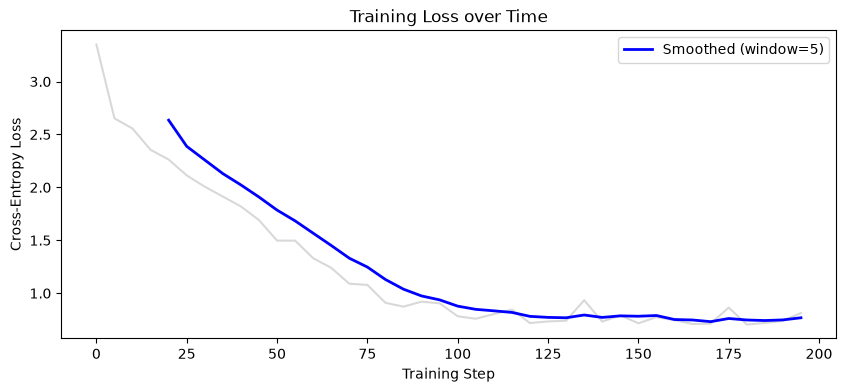

In [74]:
# Plot the training loss
plt.figure(figsize=(10, 4))
plt.plot(stepi, lossi, alpha=0.3, color='gray')

# Smoothed loss (moving average)
window = 5
if len(lossi) >= window:
    smoothed = np.convolve(lossi, np.ones(window)/window, mode='valid')
    plt.plot(stepi[window-1:], smoothed, 'b-', linewidth=2, label=f'Smoothed (window={window})')

plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss over Time')
plt.legend()
plt.show()

## 7. Generating Names

To generate a batch of names, we:
1. Start with the `.` (start-of-sequence) token for all rows in the batch
2. Feed it through the model to get logits for the next character
3. Sample from the probability distribution (with optional temperature)
4. Repeat until we sample `.` (end-of-sequence)

**Temperature** controls randomness: low temperature → more conservative/deterministic, high temperature → more diverse/random.

In [75]:
from IPython.display import clear_output

@torch.no_grad()
def generate_names(model, n=5, temperature=1.0, max_len=20, verbose=False):
    model.eval()                              # switch the model to eval mode (internally setting `self.training=False`)
    device = next(model.parameters()).device

    h = torch.zeros(n, model.hidden_size, device=device)
    c = torch.zeros(n, model.hidden_size, device=device)

    idx = torch.zeros(n, dtype=torch.long, device=device)         # start token 0 => '.' for every sequence
    finished = torch.zeros(n, dtype=torch.bool, device=device)    # tensor of (n,) that flags each sequence for EOS
    generated = [[] for _ in range(n)]                            # empty list of (n,) for storing n names
    
    for timestep in range(max_len):
        x = model.emb(idx)                     # (n, emb_size)
        h, c = model.lstm_cell(x, (h, c))
        logits = model.fc(h) / temperature     # (n, vocab_size)
        logits[:, PAD_IDX] = float('-inf')     # block PAD_IDX from being sampled; try logits[:, 1] = float('-inf') to avoid 'a'
        probs = F.softmax(logits, dim=-1)
        # print(f'probs.shape: {probs.shape}')   # expecting (n, vocab_size)
        # print(probs.sum(dim=1))                # (n, 1) equivalent of tensor.ones(n,)
        idx = torch.multinomial(probs, num_samples=1).squeeze(-1) # squeeze(-1) converts the (n, 1) -> (n,)
        # print(f'iots[idx]: {[itos[id.item()] for id in idx]}')

        finished |= (idx == 0)                 # element-wise OR gate between finished and idx to mark any sequence that hit EOS
        for b in range(n):
            if not finished[b]:
                generated[b].append(itos[idx[b].item()])

        if verbose:
            # show each sequence's progress so far,
            clear_output(wait=True)
            snapshot = [''.join(g) for g in generated]
            width = max(len(s) for s in snapshot) if snapshot else 0
            for s in snapshot:
                print(s.ljust(width))
            time.sleep(0.5)  # slow it down enough to watch
            
        if finished.all():
            break

    model.train()                               # switching the model back to training mode
    return [''.join(g) for g in generated]      # [('e', 'm', 'i', 'l', 'y'),..] => [('emily'),..]

In [77]:
names = generate_names(model, n=7, temperature=1.5, verbose=True)      # Try temperatures [0.3, 0.7, 1.0, 1.5]

jayden  
riley   
geneline
genesis 
bigva   
asher   
ella    


Generated 99/100 valid names (length >= 2)

Sample of generated names:
  ['harper', 'asher', 'olivia', 'allison']
  ['james', 'nova', 'cloe', 'mason']
  ['sophia', 'grace', 'gianna', 'owen']
  ['nathan', 'skylar', 'adam', 'samuel']
  ['mason', 'noah', 'genesis', 'olivia']


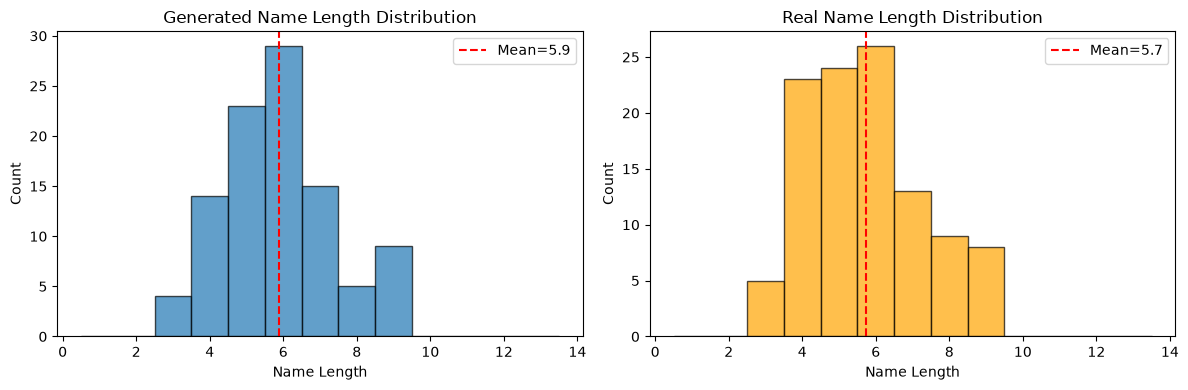

In [78]:
# Generate a larger batch and show distribution
generated_names = generate_names(model, n=100, temperature=0.8)

# Filter out empty or very short names
valid_names = [n for n in generated_names if len(n) >= 2]
print(f'Generated {len(valid_names)}/100 valid names (length >= 2)')
print(f'\nSample of generated names:')
for i in range(0, min(20, len(valid_names)), 4):
    batch = valid_names[i:i+4]
    print(f'  {batch}')

# Length distribution
lengths = [len(n) for n in valid_names]
if lengths:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.hist(lengths, bins=range(1, 15), align='left', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Name Length'); ax1.set_ylabel('Count')
    ax1.set_title('Generated Name Length Distribution')
    ax1.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean={np.mean(lengths):.1f}')
    ax1.legend()

    # Real name length distribution for comparison
    real_lengths = [len(w) for w in words]
    ax2.hist(real_lengths, bins=range(1, 15), align='left', edgecolor='black', alpha=0.7, color='orange')
    ax2.set_xlabel('Name Length'); ax2.set_ylabel('Count')
    ax2.set_title('Real Name Length Distribution')
    ax2.axvline(np.mean(real_lengths), color='red', linestyle='--', label=f'Mean={np.mean(real_lengths):.1f}')
    ax2.legend()
    plt.tight_layout()
    plt.show()

## 8. Validation: Comparing with PyTorch's Built-in `nn.LSTM`

The ultimate test: does our from-scratch LSTM behave like PyTorch's battle-tested implementation? We'll create an equivalent model using `nn.LSTM` and compare:
1. Parameter counts
2. Training loss curves
3. Quality of generated names

Note: PyTorch's `nn.LSTM` combines all four gate weight matrices into one large matrix for efficiency: $W_{combined} = [W_f; W_i; W_C; W_o]$. Mathematically, this is identical to our four separate weight matrices.

In [79]:
class CharLSTM_PyTorch(nn.Module):
    """Same architecture but using PyTorch's built-in nn.LSTM.
    
    This is our ground truth for comparison.
    """
    def __init__(self, input_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(input_size, emb_size)
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x):
        # x: (batch, seq_len)
        embs = self.emb(x)  # (batch, seq_len, emb_size)
        # nn.LSTM expects (seq_len, batch, input_size)
        B, T, C = embs.shape
        
        output, (h_n, c_n) = self.lstm(embs)  # (seq_len, 1, hidden)
        # output = output.squeeze(1)  # (seq_len, hidden_size)
        logits = self.fc(output)    # (seq_len, vocab_size)
        # print(f'logits.shape: {logits.shape}')
        return logits
        # return logits[:-1]  # drop last prediction (no target for it)

# Compare parameter counts
model_ours = charLSTM(vocab_size, 24, 128)
model_pytorch = CharLSTM_PyTorch(vocab_size, 24, 128)

params_ours = sum(p.numel() for p in model_ours.parameters())
params_pytorch = sum(p.numel() for p in model_pytorch.parameters())

print(f'Our LSTM:      {params_ours:>8,} parameters')
print(f'PyTorch LSTM:  {params_pytorch:>8,} parameters')
print(f'\nDifference is due to PyTorch combining gate weight matrices internally.')

Our LSTM:        82,620 parameters
PyTorch LSTM:    83,132 parameters

Difference is due to PyTorch combining gate weight matrices internally.


In [80]:
model_pt = CharLSTM_PyTorch(vocab_size, emb_size=24, hidden_size=128)
optimizer_pt = torch.optim.Adam(model_pt.parameters(), lr=0.01)
lossi_pt = []
stepi_pt=[]

t0 = time.time()
batch_size = 32  # tune to taste
num_epochs = 50
total_steps_pt = 0


for epoch in range(num_epochs):
    random.shuffle(words)
    epoch_loss = 0.0
    num_batches = 0

    for batch_start in range(0, len(words), batch_size):
        batch_words = words[batch_start:batch_start + batch_size]

        # Encode each name, keep track of TRUE (unpadded) lengths
        encoded_names = [torch.tensor(encode(name)) for name in batch_words]

        # Pad to the longest sequence in this batch → (B, T)
        idx_batch_seq_pt = pad_sequence(encoded_names, batch_first=True, padding_value=PAD_IDX)

        inputs_pt = idx_batch_seq_pt[:, :-1]           # (B, T-1)
        targets_pt = idx_batch_seq_pt[:, 1:].clone()   # (B, T-1)
        targets_pt[targets_pt == PAD_IDX] = -100

        # Forward pass
        logits_pt = model_pt(inputs_pt)  # (B, T-1, vocab_size)
        # logits_pt = logits_pt[:len(targets)]

        # Flatten batch and time together for cross_entropy
        loss_pt = F.cross_entropy(
            logits_pt.reshape(-1, logits_pt.size(-1)),
            targets_pt.reshape(-1),
            ignore_index=-100
        )

        # Backward pass
        optimizer_pt.zero_grad()
        loss_pt.backward()
        optimizer_pt.step()

        epoch_loss += loss_pt.item()
        num_batches += 1

        if total_steps_pt % 5 == 0:
            lossi_pt.append(loss_pt.item())
            stepi_pt.append(total_steps_pt)
        total_steps_pt += 1


    avg_loss = epoch_loss / num_batches   # per-batch average, not per-name
    if (epoch + 1) % 5 == 0 or (epoch == 0):
        print(f'Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.4f} | '
              f'Time: {time.time()-t0:.1f}s | steps: {total_steps_pt}')

elapsed = time.time() - t0
print(f'\nTraining complete in {elapsed:.1f}s ({total_steps_pt} total steps)')

Epoch  1/50 | Loss: 3.0932 | Time: 0.2s | steps: 4
Epoch  5/50 | Loss: 2.2367 | Time: 0.4s | steps: 20
Epoch 10/50 | Loss: 1.7528 | Time: 0.7s | steps: 40
Epoch 15/50 | Loss: 1.2688 | Time: 0.9s | steps: 60
Epoch 20/50 | Loss: 0.9197 | Time: 1.2s | steps: 80
Epoch 25/50 | Loss: 0.8148 | Time: 1.6s | steps: 100
Epoch 30/50 | Loss: 0.7704 | Time: 1.9s | steps: 120
Epoch 35/50 | Loss: 0.7573 | Time: 2.0s | steps: 140
Epoch 40/50 | Loss: 0.7711 | Time: 2.2s | steps: 160
Epoch 45/50 | Loss: 0.7180 | Time: 2.5s | steps: 180
Epoch 50/50 | Loss: 0.7296 | Time: 2.7s | steps: 200

Training complete in 2.7s (200 total steps)


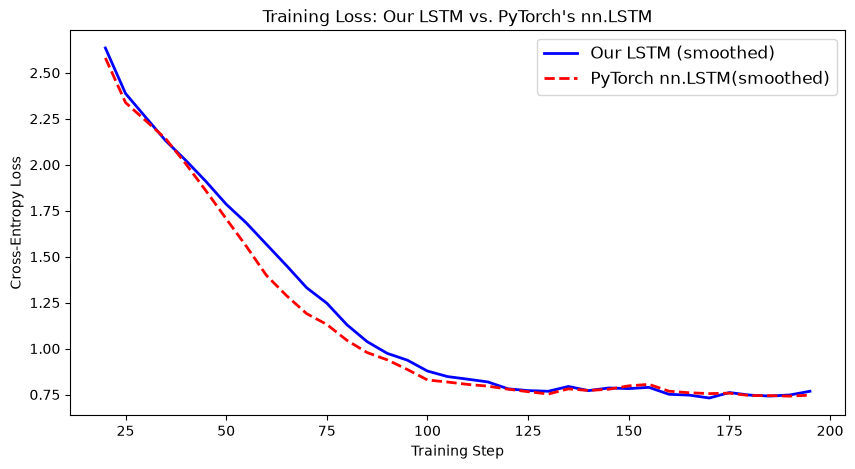

In [81]:
# Compare training curves
plt.figure(figsize=(10, 5))

# # Smooth both loss curves
# window = 5
window = 5
if len(lossi) >= window:
    smooth_ours = np.convolve(lossi, np.ones(window)/window, mode='valid')
    plt.plot(stepi[window-1:], smooth_ours, 'b-', linewidth=2, label='Our LSTM (smoothed)')
    
if len(lossi_pt) >= window:
    smooth_pt = np.convolve(lossi_pt, np.ones(window)/window, mode='valid')
    plt.plot(stepi_pt[window-1:], smooth_pt, 'r--', linewidth=2, label='PyTorch nn.LSTM(smoothed)')
    
# Uncomment the below to see the raw (not smoothed) loss curves in both our LSTM and Pytorch's variant.
# plt.plot(stepi, lossi, 'b-', linewidth=2, label='Our LSTM (from scratch)')
# plt.plot(stepi_pt, lossi_pt, 'r--', linewidth=2, label='PyTorch nn.LSTM')

plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss: Our LSTM vs. PyTorch\'s nn.LSTM')
plt.legend(fontsize=12)
plt.show()

### 8.1 Generate names with PyTorch model

In [82]:
# Generate names with PyTorch's version for qualitative comparison
@torch.no_grad()
def generate_name_pt(model, temperature=0.8, n=50, max_len=20):
    model.eval()
    h = torch.zeros(1, n, model.lstm.hidden_size)  # (num_layers, B, H) — 3D, once
    c = torch.zeros(1, n, model.lstm.hidden_size)  # (num_layers, B, H) — 3D, once
    idx = torch.zeros(n, dtype=torch.long)         # (B, ) start token 0 => '.' for every sequence in the batch
    finished = torch.zeros(n, dtype=torch.bool)    # tensor of (n,) that flags each sequence for EOS
    generated = [[] for _ in range(n)]
    
    for timestep in range(max_len):
        x = model.emb(idx).unsqueeze(1)                         # (B, emb_size) => unsqueeze(1 , "seq_len dim") => (B, 1, emb_size)
        # print(f'x.shape: {x.shape}')                          
        # print(f'h.shape: {h.shape}')                          # (1, B, H_out)  , 1 -> Direction∗num_layers
    
        output, (h, c) = model.lstm(x, (h, c))                  # (h & c).shape => (D∗num_layers, B, H_out)
        # print(f'after first timestep: h.shape: {h.shape}')    # h, c stay (1, B, H) throughout — no re-unsqueeze
        
        logits = model.fc(h.squeeze(0)) / temperature           # (B, H) → squeeze layer dim for fc
        # print(f'logits.shape: {logits.shape}')
        
        probs = F.softmax(logits, dim=-1)
        idx = torch.multinomial(probs, num_samples=1).squeeze(-1)
        # print(f'idx.shape: {idx.shape}')

        finished |= (idx == 0)                 # element-wise OR gate between finished and idx to mark any sequence that hit EOS
        for b in range(n):
            if not finished[b]:
                generated[b].append(itos[idx[b].item()])
        
        if finished.all():
            break

    model.train()                               # switching the model back to training mode
    return [''.join(g) for g in generated]      # [('e', 'm', 'i', 'l', 'y'),..] => [('emily'),..]


print('Generated names comparison (temperature=0.8):')
print(f'{"Our LSTM":<40} {"PyTorch nn.LSTM":<40}')
print('-' * 80)

ours = generate_names(model, temperature=0.8, n=32)
theirs = generate_name_pt(model_pt, temperature=0.8, n=32)

for i in range(8):
    print(f'{ours[i]:<40} {theirs[i]:<40}')

Generated names comparison (temperature=0.8):
Our LSTM                                 PyTorch nn.LSTM                         
--------------------------------------------------------------------------------
adam                                     mason                                   
sarah                                    alexander                               
charlotte                                caroline                                
madelyn                                  jack                                    
aberla                                   liam                                    
gabriella                                lena                                    
theo                                     logan                                   
sarah                                    theo                                    


## 9. Visualizing What the Gates Are Doing

One of the most educational things you can do is peek inside the LSTM during forward pass and see what each gate is deciding. Let's hook into our custom LSTMCell and visualize the gate activations.

In [83]:
def forward_with_gates(model, name):
    """Run a name through the model and collect all gate activations.
    
    Returns:
        dict with keys: 'forget', 'input', 'candidate', 'output', 'cell_state', 'hidden_state'
        Each value is a list of tensors (one per time step)
    """
    model.eval()
    encoded_name = encode(name)
    embs = model.emb(torch.tensor(encoded_name))
    
    h = torch.zeros(1, model.hidden_size)
    C = torch.zeros(1, model.hidden_size)
    
    gates = {'forget': [], 'input': [], 'candidate': [], 'output': [],
             'cell_state': [], 'hidden_state': [], 'chars': []}
    
    with torch.no_grad():
        for t in range(len(encoded_name) - 1):
            x_t = embs[t].unsqueeze(0)
            
            # Manually step through our LSTMCell to capture gate values
            combined = torch.cat([x_t, h], dim=-1)
            f_t = torch.sigmoid(model.lstm_cell.W_f(combined))
            i_t = torch.sigmoid(model.lstm_cell.W_i(combined))
            c_tilde = torch.tanh(model.lstm_cell.W_g(combined))
            C = f_t * C + i_t * c_tilde
            o_t = torch.sigmoid(model.lstm_cell.W_o(combined))
            h = o_t * torch.tanh(C)
            
            gates['forget'].append(f_t.squeeze(0))
            gates['input'].append(i_t.squeeze(0))
            gates['candidate'].append(c_tilde.squeeze(0))
            gates['output'].append(o_t.squeeze(0))
            gates['cell_state'].append(C.squeeze(0))
            gates['hidden_state'].append(h.squeeze(0))
            gates['chars'].append(itos[encoded_name[t]])
    
    model.train()
    return gates

# Analyze a few names
for name in ['emma', 'kyle', 'alexander']:
    if name in words:
        gates = forward_with_gates(model, name)
        print(f'\n"{name}":')
        for t, ch in enumerate(gates['chars']):
            f_mean = gates['forget'][t].mean().item()
            i_mean = gates['input'][t].mean().item()
            o_mean = gates['output'][t].mean().item()
            print(f'  t={t} char="{ch}": forget={f_mean:.3f} input={i_mean:.3f} output={o_mean:.3f}')


"emma":
  t=0 char=".": forget=0.443 input=0.514 output=0.413
  t=1 char="e": forget=0.575 input=0.795 output=0.611
  t=2 char="m": forget=0.618 input=0.772 output=0.701
  t=3 char="m": forget=0.601 input=0.818 output=0.741
  t=4 char="a": forget=0.573 input=0.830 output=0.768

"alexander":
  t=0 char=".": forget=0.443 input=0.514 output=0.413
  t=1 char="a": forget=0.521 input=0.753 output=0.564
  t=2 char="l": forget=0.630 input=0.821 output=0.761
  t=3 char="e": forget=0.659 input=0.827 output=0.668
  t=4 char="x": forget=0.596 input=0.654 output=0.730
  t=5 char="a": forget=0.585 input=0.864 output=0.680
  t=6 char="n": forget=0.493 input=0.710 output=0.667
  t=7 char="d": forget=0.504 input=0.801 output=0.723
  t=8 char="e": forget=0.580 input=0.795 output=0.627
  t=9 char="r": forget=0.564 input=0.711 output=0.761


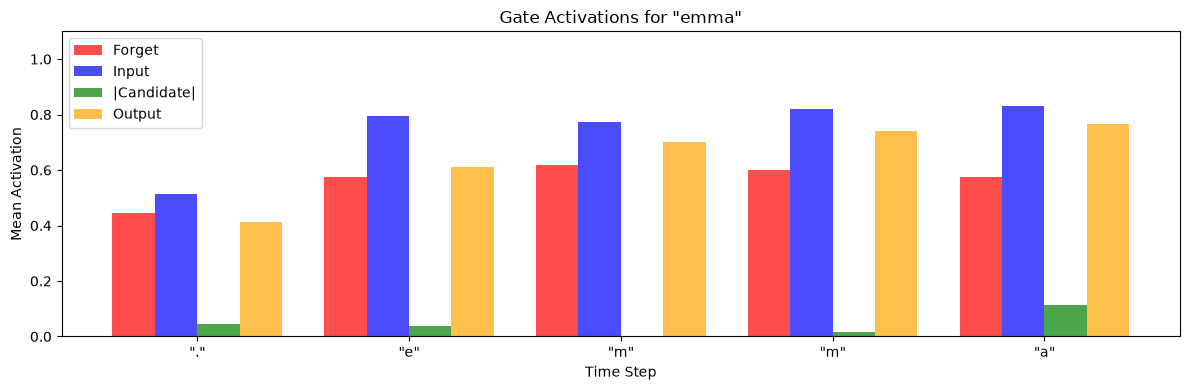

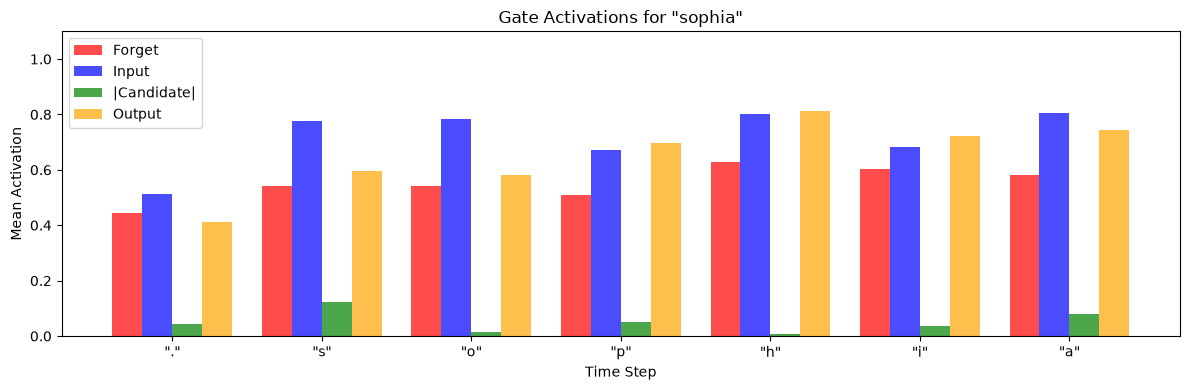

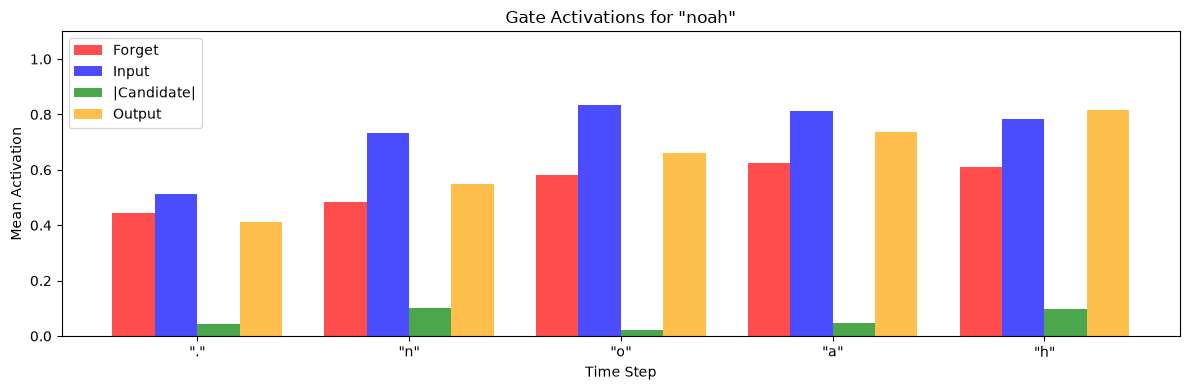

In [84]:
# Visualize gate activations as bar charts for a single name
def plot_gate_bars(gates, name):
    """Plot mean gate activations at each time step."""
    steps = len(gates['chars'])
    x = np.arange(steps)
    width = 0.2
    
    fig, ax = plt.subplots(figsize=(12, 4))
    
    f_vals = [g.mean().item() for g in gates['forget']]
    i_vals = [g.mean().item() for g in gates['input']]
    c_vals = [abs(g.mean().item()) for g in gates['candidate']]
    o_vals = [g.mean().item() for g in gates['output']]
    
    ax.bar(x - 1.5*width, f_vals, width, label='Forget', color='red', alpha=0.7)
    ax.bar(x - 0.5*width, i_vals, width, label='Input', color='blue', alpha=0.7)
    ax.bar(x + 0.5*width, c_vals, width, label='|Candidate|', color='green', alpha=0.7)
    ax.bar(x + 1.5*width, o_vals, width, label='Output', color='orange', alpha=0.7)
    
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Mean Activation')
    ax.set_title(f'Gate Activations for "{name}"')
    ax.set_xticks(x)
    ax.set_xticklabels([f'"{ch}"' for ch in gates['chars']])
    ax.legend()
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()

for name in ['emma', 'sophia', 'noah']:
    if name in words:
        gates = forward_with_gates(model, name)
        plot_gate_bars(gates, name)

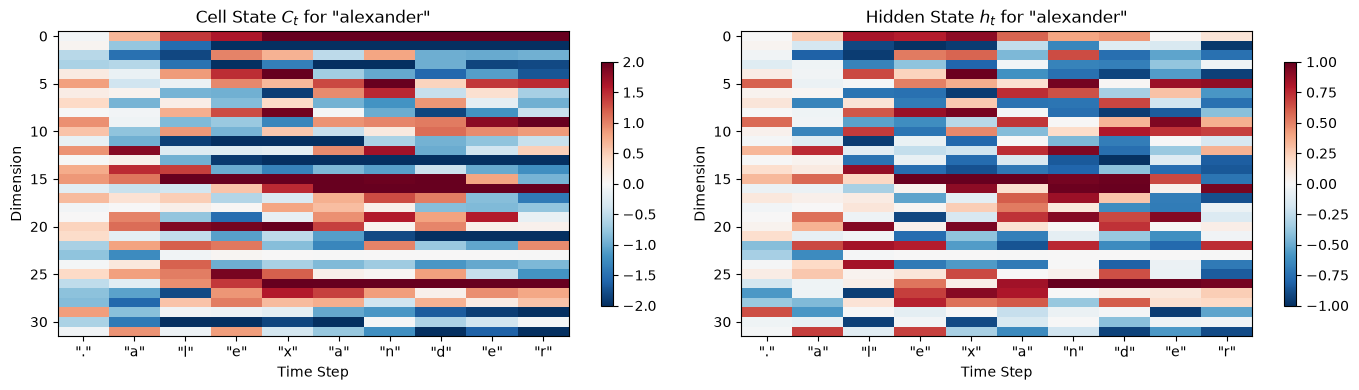

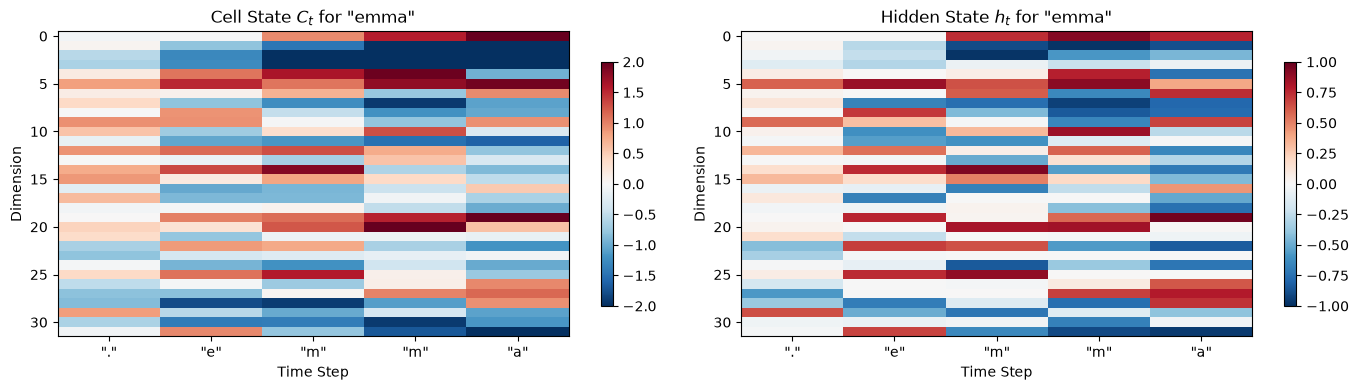

In [85]:
# Visualize cell state and hidden state evolution as heatmaps
def plot_state_heatmaps(gates, name, n_dims=32):
    """Plot cell state and hidden state as heatmaps over time."""
    steps = len(gates['chars'])
    
    C_matrix = torch.stack([g[:n_dims] for g in gates['cell_state']]).T  # (n_dims, steps)
    h_matrix = torch.stack([g[:n_dims] for g in gates['hidden_state']]).T
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    im1 = ax1.imshow(C_matrix.numpy(), cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax1.set_title(f'Cell State $C_t$ for "{name}"')
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Dimension')
    ax1.set_xticks(range(steps))
    ax1.set_xticklabels([f'"{ch}"' for ch in gates['chars']])
    plt.colorbar(im1, ax=ax1, shrink=0.8)
    
    im2 = ax2.imshow(h_matrix.numpy(), cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax2.set_title(f'Hidden State $h_t$ for "{name}"')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Dimension')
    ax2.set_xticks(range(steps))
    ax2.set_xticklabels([f'"{ch}"' for ch in gates['chars']])
    plt.colorbar(im2, ax=ax2, shrink=0.8)
    
    plt.tight_layout()
    plt.show()

for name in ['alexander', 'emma', 'li']:
    if name in words:
        gates = forward_with_gates(model, name)
        plot_state_heatmaps(gates, name, n_dims=32)

## 10. Summary

Here's what we built and learned:

**Architecture**: We built a complete LSTM from 4 separate `nn.Linear` layers, each representing a gate. No magic, no black box — just `sigmoid`, `tanh`, element-wise multiplication, and addition.

**Key insight**: The cell state $C_t$ is the secret sauce. It provides a **linear path for gradients to flow through time**. The forget gate's additive update ($f_t \cdot C_{t-1} + i_t \cdot g_t$) means the gradient $\frac{\partial C_t}{\partial C_{t-1}} = f_t$, which is just element-wise multiplication by values in [0, 1] — **no vanishing!**

**Validation**: Our from-scratch implementation achieves comparable loss and generation quality to PyTorch's `nn.LSTM`, confirming our understanding is correct.

**Visualization**: The gate activation plots reveal that the LSTM learns meaningful patterns — different gates activate differently at different positions in names, showing that the model is learning character-level structure.

## 11. What next?


1. **Layer Normalization**: Add layer norm before each gate's activation. This stabilizes training and is commonly used in practice.
2. **GRU from scratch**: The GRU (Gated Recurrent Unit) merges the cell state and hidden state into a single vector. Implement a GRU cell from scratch and compare with `nn.GRU`.
3. **Attention mechanism**: Add an attention layer on top of the LSTM outputs. This allows the model to look back at specific previous characters when making predictions.
